In [21]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.query import (
    get_hourly_ridership,
    get_busiest_stations,
    get_ridership_by_hour,
    get_ridership_by_borough
)

In [22]:
stations = get_busiest_stations()
stations

,station_complex,borough,total_ridership
0,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",Manhattan,168199492.0
1,"Grand Central-42 St (S,4,5,6,7)",Manhattan,115353598.0
2,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",Manhattan,97398981.0
3,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",Manhattan,86563072.0
4,"Fulton St (A,C,J,Z,2,3,4,5)",Manhattan,70687785.0
5,"34 St-Penn Station (A,C,E)",Manhattan,68310781.0
6,"59 St-Columbus Circle (A,B,C,D,1)",Manhattan,63618073.0
7,"34 St-Penn Station (1,2,3)",Manhattan,62793978.0
8,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...",Queens,58200035.0
9,Flushing-Main St (7),Queens,57023934.0


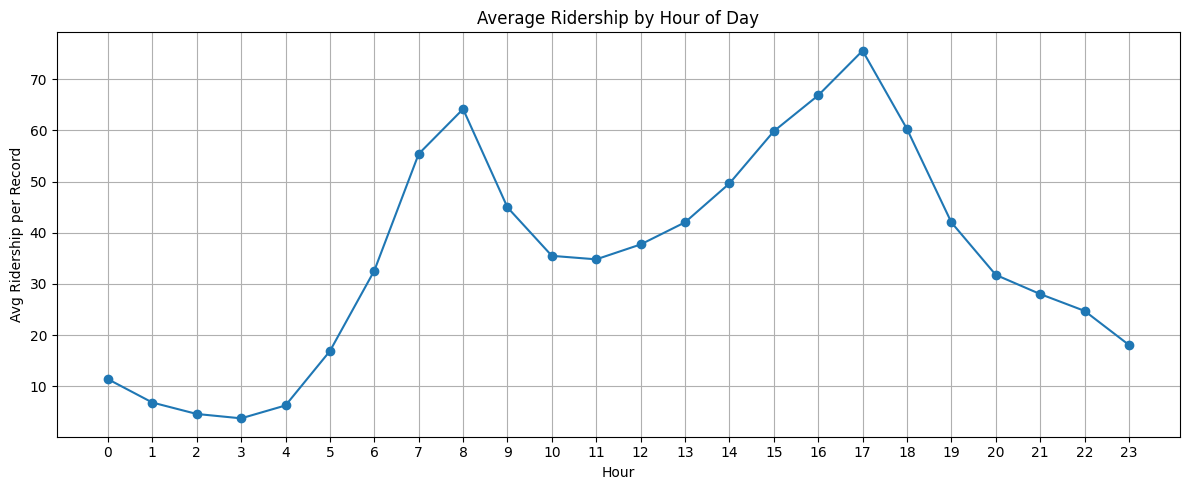

In [23]:
hourly = get_ridership_by_hour()

plt.figure(figsize=(12, 5))
plt.plot(hourly['hour_of_day'], hourly['avg_ridership'], marker='o')
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership per Record')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

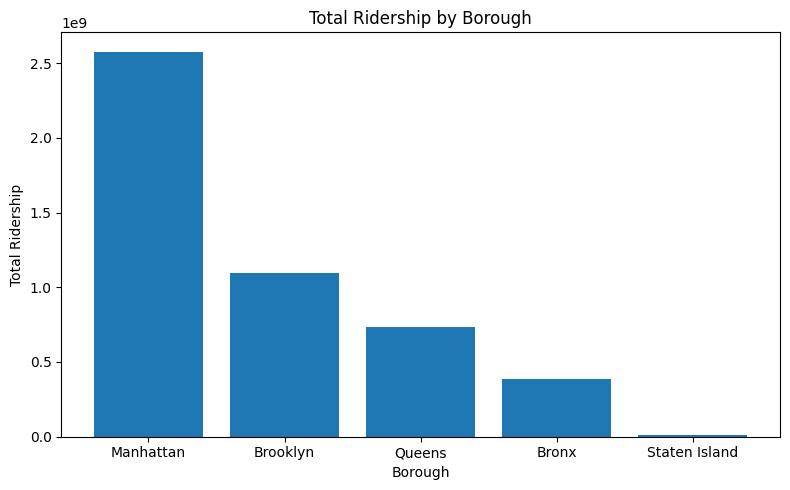

In [24]:
borough = get_ridership_by_borough()

plt.figure(figsize=(8, 5))
plt.bar(borough['borough'], borough['total_ridership'])
plt.title('Total Ridership by Borough')
plt.xlabel('Borough')
plt.ylabel('Total Ridership')
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

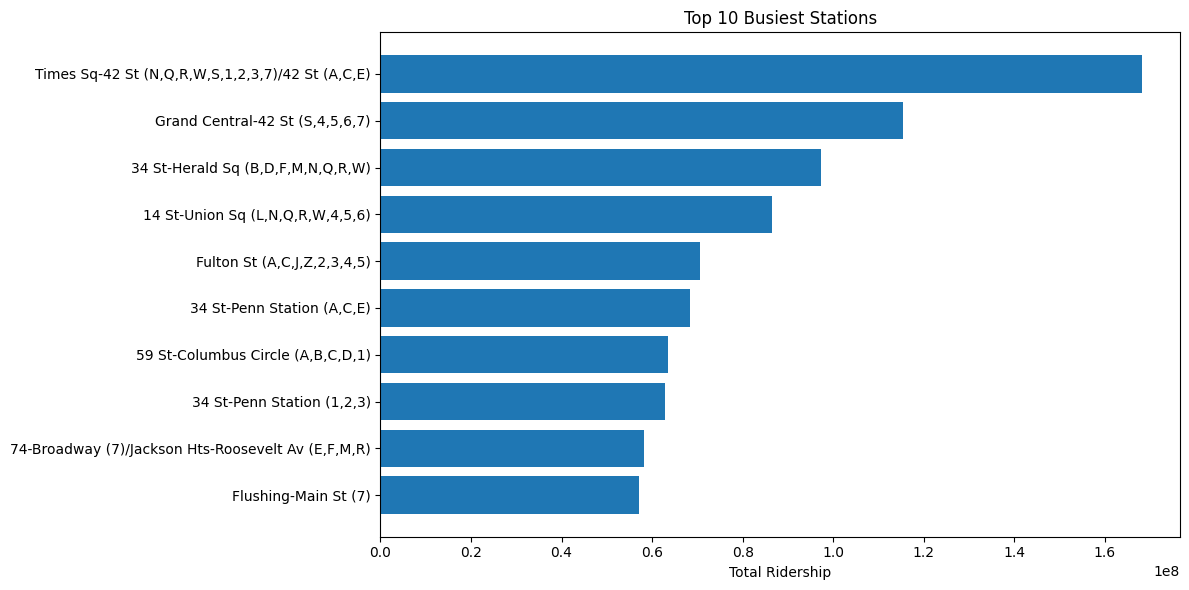

In [25]:
stations = get_busiest_stations(limit=10)

plt.figure(figsize=(12, 6))
plt.barh(stations['station_complex'], stations['total_ridership'])
plt.title('Top 10 Busiest Stations')
plt.xlabel('Total Ridership')
plt.gca().invert_yaxis()  # busiest at top
plt.tight_layout()
plt.show()

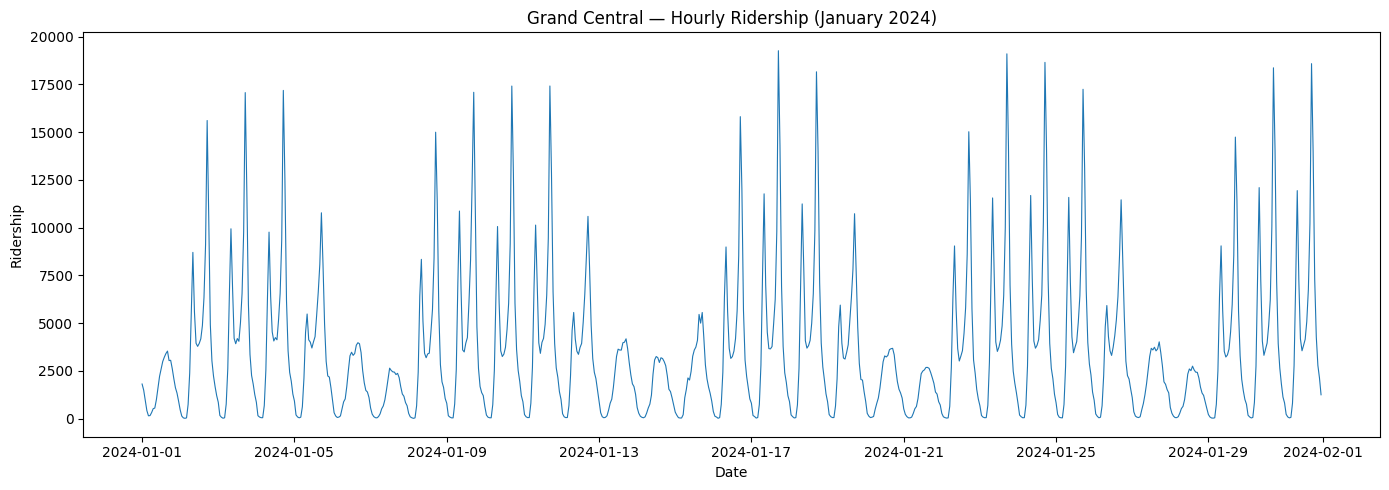

In [26]:
gc = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-02-01"
)

plt.figure(figsize=(14, 5))
plt.plot(gc['transit_timestamp'], gc['ridership'], linewidth=0.8)
plt.title('Grand Central — Hourly Ridership (January 2024)')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.tight_layout()
plt.show()

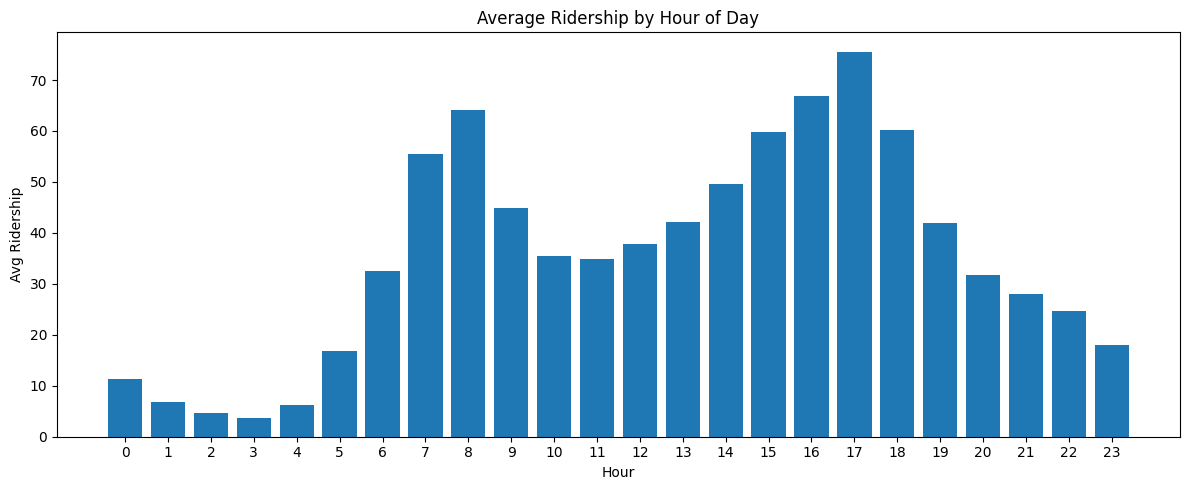

In [27]:
hourly = get_ridership_by_hour()

# We'll add day of week breakdown to query.py soon, but for now:
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour_of_day'], hourly['avg_ridership'])
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

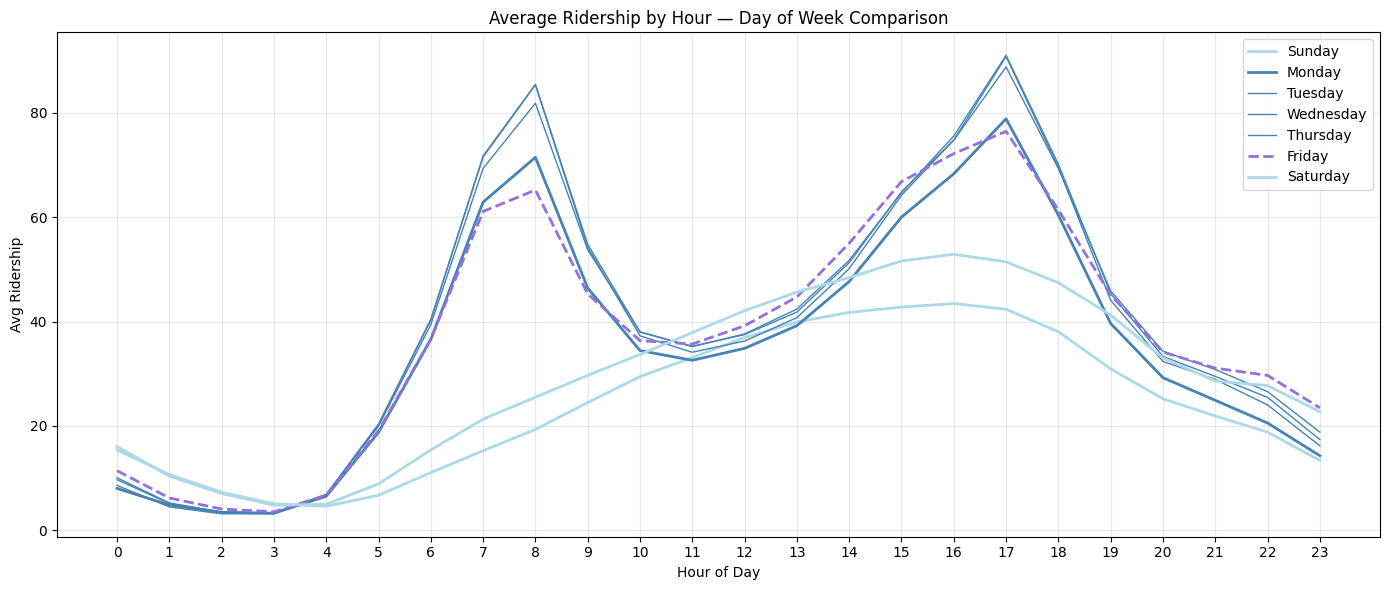

In [28]:
from src.query import get_ridership_by_day_of_week

dow = get_ridership_by_day_of_week()

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
colors = ['lightblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'mediumpurple', 'lightblue']

plt.figure(figsize=(14, 6))
for i, day in enumerate(days):
    day_data = dow[dow['day_name'] == day]
    plt.plot(day_data['hour_of_day'], day_data['avg_ridership'], 
             label=day, color=colors[i], 
             linewidth=2 if day in ['Monday','Friday', 'Saturday', 'Sunday'] else 1,
             linestyle='--' if day == 'Friday' else '-')

plt.title('Average Ridership by Hour — Day of Week Comparison')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Day of Week Patterns

- Clear AM/PM commute peaks on Tue-Thu
- Monday and Friday show reduced ridership — likely driven by WFH patterns
- Friday evening peak comparable to Mon-Thu morning peak
- Feature engineering implication: day of week should be one-hot encoded 
  or grouped (core weekday / shoulder day / weekend) rather than treated as ordinal

In [29]:
from src.query import get_hourly_ridership
from src.features import add_time_features

df = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-02-01"
)
df = add_time_features(df)
df.head()

,transit_timestamp,station_complex,ridership,hour,day_of_week,month,week_of_year,is_weekend,is_shoulder_day,day_mon,day_tue,day_wed,day_thu,day_fri,day_sat,day_sun,hour_sin,hour_cos,month_sin,month_cos
0,2024-01-01 00:00:00,"Grand Central-42 St (S,4,5,6,7)",1815.0,0,0,1,1,0,1,1,0,0,0,0,0,0,0.000000,1.000000,0.5,0.866025
1,2024-01-01 01:00:00,"Grand Central-42 St (S,4,5,6,7)",1495.0,1,0,1,1,0,1,1,0,0,0,0,0,0,0.258819,0.965926,0.5,0.866025
2,2024-01-01 02:00:00,"Grand Central-42 St (S,4,5,6,7)",962.0,2,0,1,1,0,1,1,0,0,0,0,0,0,0.500000,0.866025,0.5,0.866025
3,2024-01-01 03:00:00,"Grand Central-42 St (S,4,5,6,7)",425.0,3,0,1,1,0,1,1,0,0,0,0,0,0,0.707107,0.707107,0.5,0.866025
4,2024-01-01 04:00:00,"Grand Central-42 St (S,4,5,6,7)",153.0,4,0,1,1,0,1,1,0,0,0,0,0,0,0.866025,0.500000,0.5,0.866025


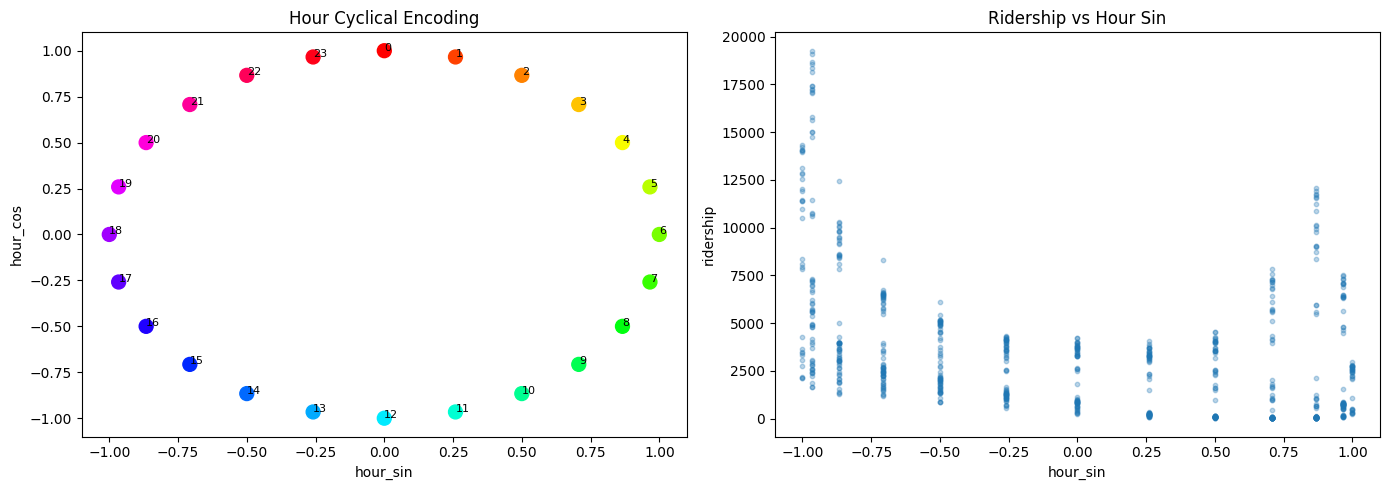

In [30]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour encoding
hours = range(24)
hour_sin = [np.sin(2 * np.pi * h / 24) for h in hours]
hour_cos = [np.cos(2 * np.pi * h / 24) for h in hours]

axes[0].scatter(hour_sin, hour_cos, c=hours, cmap='hsv', s=100)
for h in hours:
    axes[0].annotate(str(h), (hour_sin[h], hour_cos[h]), fontsize=8)
axes[0].set_title('Hour Cyclical Encoding')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')

# Ridership by hour_sin — does the model see a clean signal?
axes[1].scatter(df['hour_sin'], df['ridership'], alpha=0.3, s=10)
axes[1].set_title('Ridership vs Hour Sin')
axes[1].set_xlabel('hour_sin')
axes[1].set_ylabel('ridership')

plt.tight_layout()
plt.show()

C:\Users\rayz2\AppData\Local\Temp\ipykernel_19016\3572228733.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_day, labels=day_names)


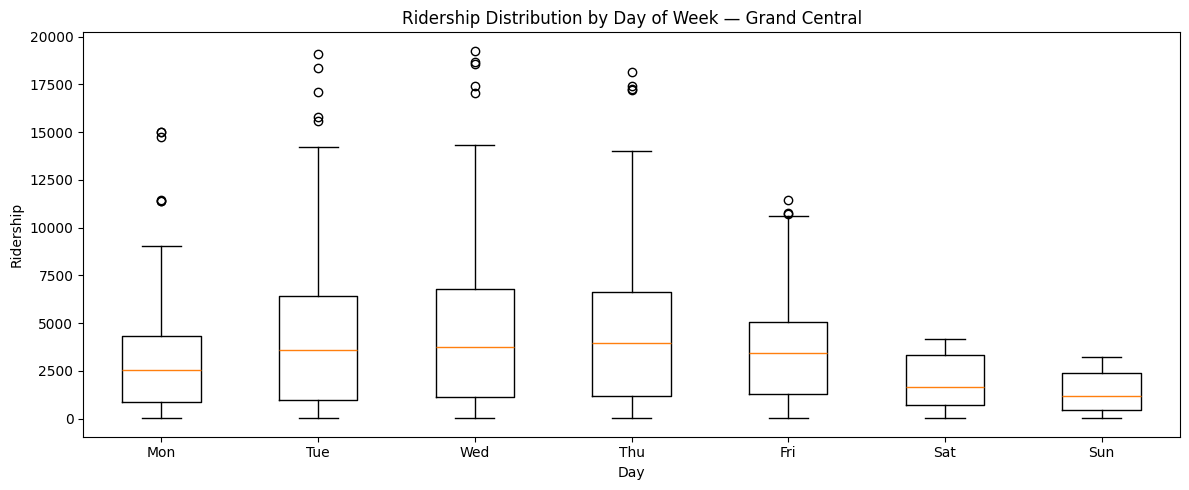

In [31]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(12, 5))
data_by_day = [df[df['day_of_week'] == i]['ridership'].values for i in range(7)]
ax.boxplot(data_by_day, labels=day_names)
ax.set_title('Ridership Distribution by Day of Week — Grand Central')
ax.set_xlabel('Day')
ax.set_ylabel('Ridership')
plt.tight_layout()
plt.show()

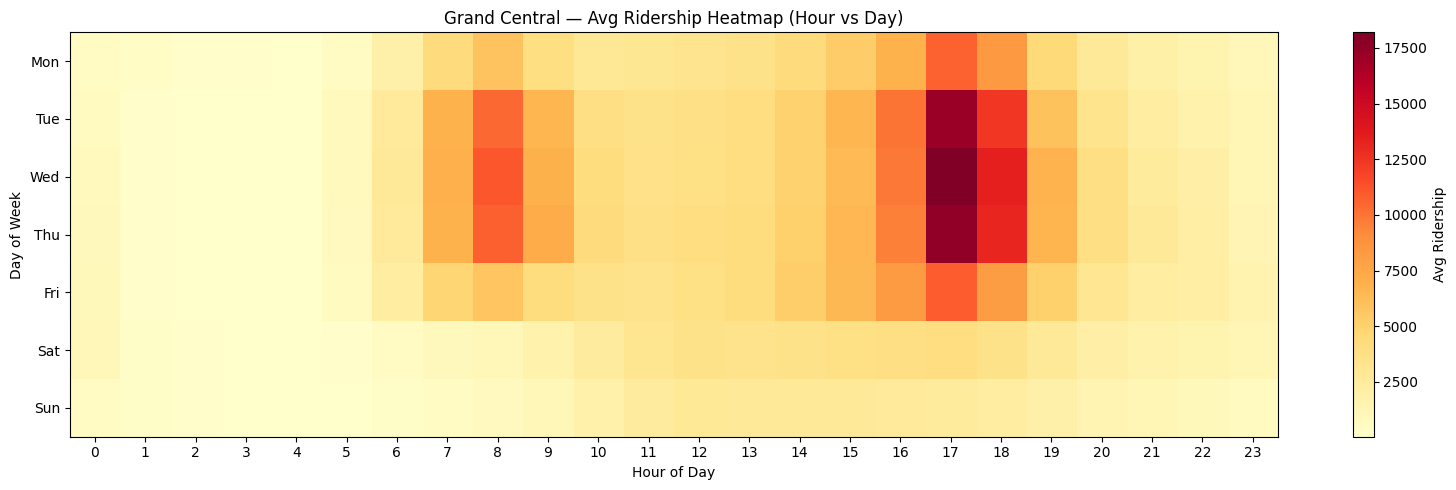

In [32]:
pivot = df.groupby(['day_of_week', 'hour'])['ridership'].mean().unstack()
pivot.index = day_names

plt.figure(figsize=(16, 5))
plt.imshow(pivot, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Avg Ridership')
plt.title('Grand Central — Avg Ridership Heatmap (Hour vs Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.xticks(range(24))
plt.yticks(range(7), day_names)
plt.tight_layout()
plt.show()

## Congestion Heatmap — Grand Central

Ridership is heavily concentrated on Tuesday-Thursday during morning (8am) 
and evening (5-6pm) rush hours. Weekend ridership is significantly lower 
and more evenly distributed across the day, consistent with Grand Central's 
role as a commuter hub serving Metro-North passengers.